# Activity : Pytorch and CNNs for Fashion-MNIST

In this activity, we are going to explore designing various neural networks for the FashionMNIST classification problem. This is, of course, a 'toy' problem, but the fundamentals of classification of images is here.


# Common Code 

All the imports

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, transforms
from torchsummary import summary
import matplotlib.pyplot as plt
from torchvision import models

### 1. Select the device to use.

To access the GPU on Google Colab, `Select Runtime` -> `Change Runtime Type` and pick `GPU` from the `Hardware Accelerator` dropdown menu. In the free version, the GPU is modest. If you buy credits, you get access to a much nice A100 GPU. In both cases, you may find contention for the resource is an issue, but less likely to happen if you use credits.

In [2]:
# Get appropriate device for training
device = ( "cuda"     # CUDA is a programming interface for certain Nvidia GPUs
           if torch.cuda.is_available()
           else "mps"  # Kind of like CUDA for a mac, I guess? I don't use macs
           if torch.backends.mps.is_available()
           else "cpu" )   # If you end up with CPU, go use Google Colab and get a GPU

print(f"{device} device available")

cuda device available


### 2. Code for training the models

I'm going to provide this code, rather than you having to struggle creating it. This is a normal training cycle with PyTorch. However, I do want you to explain the PyTorch functions called in the train function. I will marke them with comments.

In [3]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()        #<--- what is this function for?

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)   #<--- this is a bit funny, explain it

        # Compute prediction error
        pred = model(X)                     #<--- what is this for?
        loss = loss_fn(pred, y)             #<--- what is this for?

        # This is the backprop set up. Explain what each of the steps do
        loss.backward()                     #<--- what is this for?
        optimizer.step()                    #<--- what is this for?
        optimizer.zero_grad()               #<--- what is this for?

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    loss, accuracy = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()
    loss /= num_batches
    accuracy /= size

    return loss, accuracy

def train_loop(train_dataloader, test_dataloader, model, loss_fn, optimizer, epochs):
    train_loss = []
    train_accuracy = []
    test_loss = []
    test_accuracy = []

    # Iterate over each epoch
    for t in range(epochs):
        print(f"Epoch {t+1}:\n")
        train(train_dataloader, model, loss_fn, optimizer)

        # Get the overall loss and accuracy for both train and test datasets
        tr_loss, tr_acc = test(train_dataloader, model, loss_fn)
        ts_loss, ts_acc = test(test_dataloader, model, loss_fn)

        print(f"Train Error: \n Accuracy: {(100*tr_acc):>0.1f}%, Avg loss: {tr_loss:>8f} \n")
        print(f"Test Error: \n Accuracy: {(100*ts_acc):>0.1f}%, Avg loss: {ts_loss:>8f} \n")

        # Store and return the losses and accuracies. We can graph these later
        train_loss = train_loss + [tr_loss]
        train_accuracy = train_accuracy + [tr_acc]
        test_loss = test_loss + [ts_loss]
        test_accuracy = test_accuracy + [ts_acc]

    print("Done training!")
    return train_loss, train_accuracy, test_loss, test_accuracy



### 3. Load the data

1. Load the Fashion-MNIST dataset using `torchvision`'s `datasets` library (e.g., [`datasets.FashionMNIST...`](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)...)
2. When loading the data, convert it to tensor format ([`transforms.ToTensor`](https://pytorch.org/vision/stable/generated/torchvision.transforms.ToTensor.html)), and apply the standard scaler to the data (using [`transforms.Normalize`](https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html)). Use the [`transforms.Resize`](https://pytorch.org/vision/main/generated/torchvision.transforms.Resize.html) transform to turn it into a 28x28 image rather than a 784-vector
    * Rather than loading the data, and caluclating the mean and std, you can use the values `mean = 0.2859` and `std = 0.3530`. I pre-calculated these for you!
3. Create the [`DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)s. Here we're going to use a batch size of 64.
4. Display a few examples of the dataset - this is always a good idea to make sure the data has loaded correctly

We haven't really touched on batch size yet, because up to now we have used plain old gradient descent. Later on, we will use the Adam optimiser, because it is quicker and uses less memory. But Adam is a mini-batch optimizer, and you have to pick that mini-batch size. Bit more info on this, if you are interested:
 * https://sebastianraschka.com/faq/docs/gradient-optimization.html
 * https://machinelearningmastery.com/adam-optimization-algorithm-for-deep-learning/

We need to set the batch size when we create the dataloaders.

In [4]:
from torchvision import datasets
from torchvision.transforms import transforms  # or: from torchvision import transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.0MB/s]


Training samples: 60000
Test samples: 10000
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


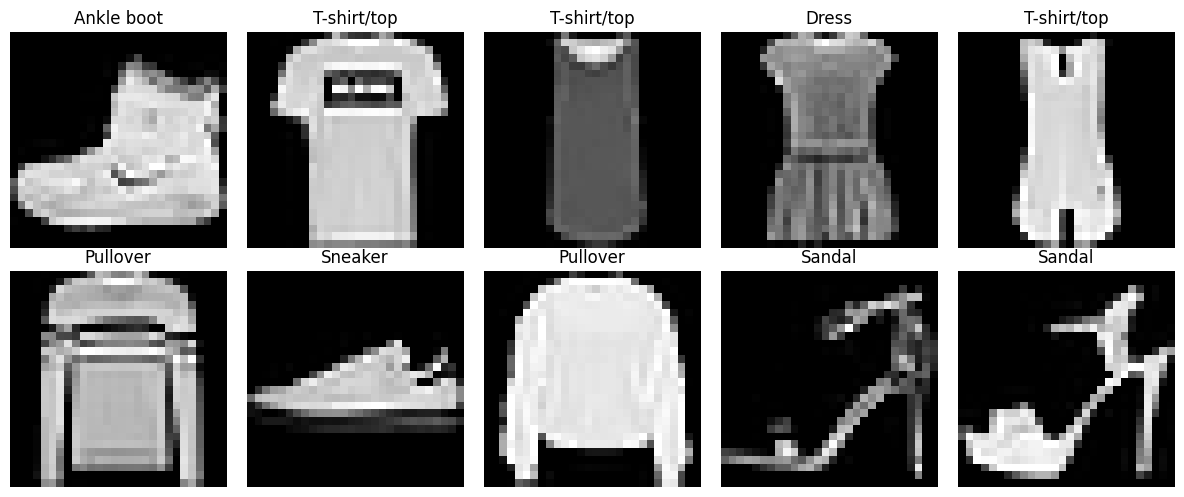

In [5]:
# Define the transformations
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.2859], std=[0.3530])
])

# Load the Fashion-MNIST training dataset
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

# Load the Fashion-MNIST test dataset
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders with batch size 64
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Display information about the loaded data
print(f"Training samples: {len(training_data)}")
print(f"Test samples: {len(test_data)}")

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

# Display a few examples of the dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i // 5, i % 5]
    img, label = training_data[i]
    img = img * 0.3530 + 0.2859  # Denormalize
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()


---
## 1. Replicate the Neural Network from the previous tasks for the FashionMNIST dataset (Weight 10/100)
---


In the previous activity, you designed a fully connected neural network (a multi-layer perceptron) to predict on Fashion-MNIST.

1. Replicate the best network that you found in that activity, but in PyTorch.
1. Use [`summary`](https://pypi.org/project/torch-summary/) to display a summary of your model.
1. Use some random inputs to test the model. This will be meaningless, as the model is not trained yet (and the inputs are random). However, it is useful to test that you have defined the model at leats without any coding errors.

Hints and notes:
 * We need to [`Flatten`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html) the incoming data. In the previous step, you loaded the dataset as a 28x28 image (because, later on we will be using CNNs that require image inputs). However, fully connected layers require vector inputs. `nn.Flatten` converts the image input to a vector (i.e., a 28x28 image to a 784 vector).
 * Use [`.to(device)`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html) to "send" objects to the GPU (if you have one). E.g., once you define your class for the neural network, you will create an instance of that NN - you need to send this object to the GPU.
 * Generally, at inference time, we will use a [`softmax`](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html) on the output of the model. Prior to the softmax, the model outputs a score per class. That is, there will be 10 outputs. However, here we will ignore the softmax part.


In [6]:
##############################
# Your code below

import torch
from torch import nn
from torchsummary import summary

# model definition
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)   # 10 Fashion‑MNIST classes
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.classifier(x)
        return logits

# create model on training device
model = NeuralNetwork().to(device)

# --- summary on CPU to avoid mps vs cpu error ---
model_cpu = NeuralNetwork().to("cpu")
summary(model_cpu, (1, 28, 28), device="cpu")

# test the (GPU) model with random inputs
x_rand = torch.randn(4, 1, 28, 28).to(device)  # batch of 4
with torch.no_grad():
    out = model(x_rand)
print("Random output shape:", out.shape)



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
            Linear-4                  [-1, 128]          32,896
              ReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.90
Estimated Total Size (MB): 0.91
----------------------------------------------------------------
Random output shape: torch.Size([4, 10])


Now train the model.

We will use [Cross Entropy Loss](https://towardsdatascience.com/cross-entropy-loss-function-f38c4ec8643e), and as discussed, the Adam optimiser (with learning rate = 0.001).

* Call the training loop - I would suggest a max of ~20 epochs
* Use matplotlib to plot the train and test loss, and the train and test accuracy
* Describe what you see in the graphs

This training could take a few minutes. But note how you will see a bunch of losses reported in each epoch? These are the mini-batches in Adam that we discussed before. Then there will be an overall Train and Test error reported for the Epoch.

\

In [7]:
##############################
# Your code below

import torch
from torch import nn
from torchsummary import summary

# model definition
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)   # 10 Fashion‑MNIST classes
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.classifier(x)
        return logits

# create model on training device
model = NeuralNetwork().to(device)

# --- summary on CPU to avoid mps vs cpu error ---
model_cpu = NeuralNetwork().to("cpu")
summary(model_cpu, (1, 28, 28), device="cpu")

# test the (GPU) model with random inputs
x_rand = torch.randn(4, 1, 28, 28).to(device)  # batch of 4
with torch.no_grad():
    out = model(x_rand)
print("Random output shape:", out.shape)



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
            Linear-4                  [-1, 128]          32,896
              ReLU-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.90
Estimated Total Size (MB): 0.91
----------------------------------------------------------------
Random output shape: torch.Size([4, 10])


In [8]:
# Define the loss function and the optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train the model
epochs = 20
train_loss, train_accuracy, test_loss, test_accuracy = train_loop(
    train_dataloader, test_dataloader, model, loss_fn, optimizer, epochs
)



Epoch 1:

loss: 2.347614  [   64/60000]
loss: 0.573042  [ 6464/60000]
loss: 0.511436  [12864/60000]
loss: 0.451125  [19264/60000]
loss: 0.448016  [25664/60000]
loss: 0.308919  [32064/60000]
loss: 0.424670  [38464/60000]
loss: 0.367104  [44864/60000]
loss: 0.420468  [51264/60000]
loss: 0.218722  [57664/60000]
Train Error: 
 Accuracy: 87.1%, Avg loss: 0.348554 

Test Error: 
 Accuracy: 85.9%, Avg loss: 0.393193 

Epoch 2:

loss: 0.561474  [   64/60000]
loss: 0.660301  [ 6464/60000]
loss: 0.302355  [12864/60000]
loss: 0.437123  [19264/60000]
loss: 0.507085  [25664/60000]
loss: 0.402997  [32064/60000]
loss: 0.368907  [38464/60000]
loss: 0.504867  [44864/60000]
loss: 0.335289  [51264/60000]
loss: 0.432622  [57664/60000]
Train Error: 
 Accuracy: 88.6%, Avg loss: 0.306802 

Test Error: 
 Accuracy: 86.6%, Avg loss: 0.367230 

Epoch 3:

loss: 0.407261  [   64/60000]
loss: 0.146348  [ 6464/60000]
loss: 0.226990  [12864/60000]
loss: 0.372486  [19264/60000]
loss: 0.415637  [25664/60000]
loss: 0.18


---

# 2. Replicate LeNet-5 for Fashion-MNIST 

---


Below is the LeNet architecture (from https://en.wikipedia.org/wiki/LeNet). If you search on the internet, you will find slightly different implementations and descriptions of LeNet-5, but below is what was actually in LeCun's [original paper](https://ieeexplore.ieee.org/document/726791). Of course, LeCun was applying this to the digit recognition problem (MNIST), but we are looking at Fashion-MNIST.

 * Create the model in PyTorch.
 * Train the model using the same parameters as above, and plot the loss and accuracy.
 * Discuss and compare (in a markdown cell) with the fully connected model above. Particularly consider - number of parameters, performance, and overfitting?

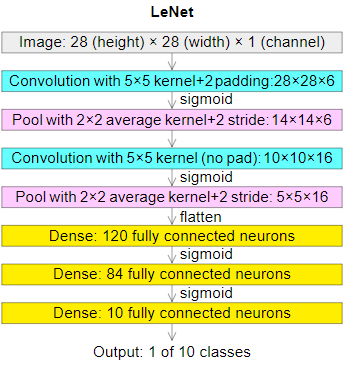

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
# You may need to install this library: !pip install torchsummary
try:
    from torchsummary import summary
except ImportError:
    print("Warning: torchsummary not found. Model summary will be skipped.")
    def summary(*args, **kwargs): pass

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # C1: Convolution (28x28 -> 28x28)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)

        # S2: Subsampling (Average Pool) (28x28 -> 14x14)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C3: Convolution (14x14 -> 10x10)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)

        # S4: Subsampling (Average Pool) (10x10 -> 5x5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Flatten layer: 16 * 5 * 5 = 400 features
        self.flatten = nn.Flatten()

        # F5: Fully Connected (400 -> 120)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # F6: Fully Connected (120 -> 84)
        self.fc2 = nn.Linear(120, 84)
        # Output: Fully Connected (84 -> 10 classes)
        self.fc3 = nn.Linear(84, 10)

        # Activation function used in the original paper
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Layer 1: Conv -> Sigmoid -> Pool
        x = self.pool1(self.sigmoid(self.conv1(x)))

        # Layer 2: Conv -> Sigmoid -> Pool
        x = self.pool2(self.sigmoid(self.conv2(x)))

        # Flatten
        x = self.flatten(x)

        # Layer 3: Dense -> Sigmoid
        x = self.sigmoid(self.fc1(x))

        # Layer 4: Dense -> Sigmoid
        x = self.sigmoid(self.fc2(x))

        # Output Layer
        logits = self.fc3(x)


In [10]:
# Assuming 'device' was defined in an earlier setup cell (e.g., device = 'cuda' if torch.cuda.is_available() else 'cpu')
# Instantiate the LeNet5 model
model = LeNet5().to(device)

# 1. Print the model architecture (standard PyTorch method)
print("Model Architecture:")
print(model)

# 2. Calculate and print the total number of trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

Model Architecture:
LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (sigmoid): Sigmoid()
)

Total Trainable Parameters: 61,706


Starting training on cuda...
Epoch 1:

loss: 2.301491  [   64/60000]
loss: 0.490805  [ 6464/60000]
loss: 0.372772  [12864/60000]
loss: 0.464663  [19264/60000]
loss: 0.319499  [25664/60000]
loss: 0.486893  [32064/60000]
loss: 0.233982  [38464/60000]
loss: 0.458496  [44864/60000]
loss: 0.365223  [51264/60000]
loss: 0.309012  [57664/60000]
Train Error: 
 Accuracy: 90.0%, Avg loss: 0.267230 

Test Error: 
 Accuracy: 88.9%, Avg loss: 0.300278 

Epoch 2:

loss: 0.212979  [   64/60000]
loss: 0.235511  [ 6464/60000]
loss: 0.278575  [12864/60000]
loss: 0.185728  [19264/60000]
loss: 0.400738  [25664/60000]
loss: 0.241087  [32064/60000]
loss: 0.245515  [38464/60000]
loss: 0.261819  [44864/60000]
loss: 0.084536  [51264/60000]
loss: 0.336160  [57664/60000]
Train Error: 
 Accuracy: 91.8%, Avg loss: 0.216529 

Test Error: 
 Accuracy: 90.8%, Avg loss: 0.256196 

Epoch 3:

loss: 0.252620  [   64/60000]
loss: 0.339316  [ 6464/60000]
loss: 0.224131  [12864/60000]
loss: 0.125477  [19264/60000]
loss: 0.315

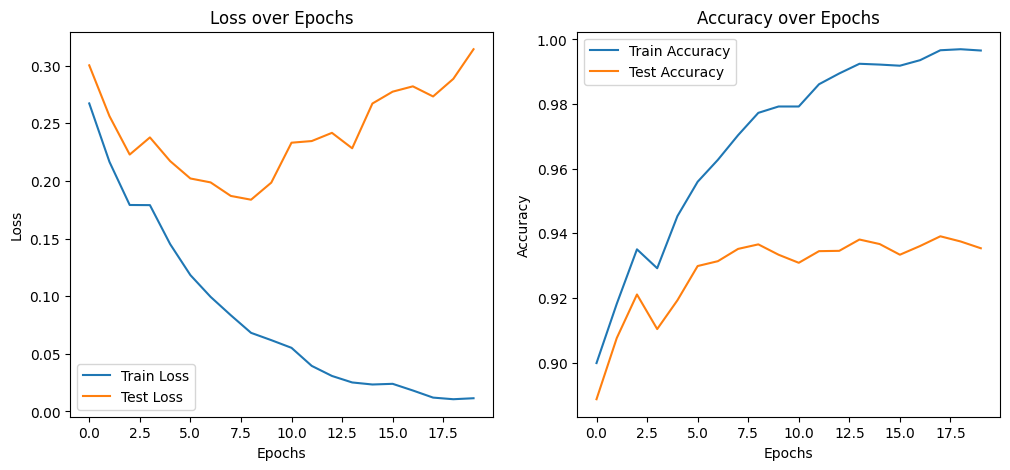

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# class custom---------------------------------------------------------------------

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Feature Extraction Layers
        self.conv_layers = nn.Sequential(
            # Layer 1: 28x28 -> 28x28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Layer 2: 28x28 -> 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Layer 3: 14x14 -> 14x14
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Layer 4: 14x14 -> 7x7 (Output size: 128 feature maps, 7x7 spatial size)
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classifier Layers (Input size: 128 * 7 * 7 = 6272)
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Regularization to prevent overfitting
            nn.Linear(512, 10)
        )

    def forward(self, x):
        # Feature Extraction
        x = self.conv_layers(x)

        # Flatten (prepare for fully connected layers)
        x = x.view(x.size(0), -1)

        # Classification
        x = self.fc_layers(x)

        # CRITICAL FIX for the original TypeError: ensure the output is returned
        return x


# Instantiate the model and move it to your selected device
model = CustomCNN().to(device)

# Define Loss Function and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train the model for 20 epochs
epochs = 20
print(f"Starting training on {device}...")
train_loss, train_acc, test_loss, test_acc = train_loop(
    train_dataloader,
    test_dataloader,
    model,
    loss_fn,
    optimizer,
    epochs
)

# Plotting the results
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Save the figure to a file
plt.savefig('custom_cnn_results.png')
print("\nTraining complete. Results saved to 'custom_cnn_results.png'.")

The provided training, testing, and loop functions implement a standard supervised learning workflow for Fashion‑MNIST in PyTorch. The training function sets the model to training mode, iterates over mini‑batches, moves data to the chosen device, performs a forward pass to obtain predictions, computes the cross‑entropy loss, and then runs backpropagation followed by an optimiser step before resetting gradients.

The test function switches the model to evaluation mode and disables gradient computation, so it only measures performance without updating weights. It accumulates the average loss and computes accuracy by comparing the predicted class indices with the true labels across the full dataset.

Finally, the train_loop function orchestrates multiple epochs: in each epoch it calls the training function, evaluates on both training and test dataloaders, logs loss and accuracy, and stores these values in lists for later plotting. This makes it straightforward to monitor convergence and identify overfitting if training accuracy rises while test accuracy stagnates or decreases.### <font color='red'>Your text here.</font>
<font color='red'>Enter your text descriptions in the cell below:</font>

The provided training, testing, and loop functions implement a standard supervised learning workflow for Fashion‑MNIST in PyTorch. The training function sets the model to training mode, iterates over mini‑batches, moves data to the chosen device, performs a forward pass to obtain predictions, computes the cross‑entropy loss, and then runs backpropagation followed by an optimiser step before resetting gradients.

The test function switches the model to evaluation mode and disables gradient computation, so it only measures performance without updating weights. It accumulates the average loss and computes accuracy by comparing the predicted class indices with the true labels across the full dataset.

Finally, the train_loop function orchestrates multiple epochs: in each epoch it calls the training function, evaluates on both training and test dataloaders, logs loss and accuracy, and stores these values in lists for later plotting. This makes it straightforward to monitor convergence and identify overfitting if training accuracy rises while test accuracy stagnates or decreases.

---
# 3. Modernise LeNet 
---


Modernise LeNet. What are the preferred activation and pooling functions for modern CNNs?

* Update LeNet with these newer functions.
* Train using the same parameters as above.
* Compare and discuss with the above using the normal discussion criteria


### <font color='red'>Your code here.</font>
<font color='red'>Enter your code in the cell(s) below:</font>

In [12]:
##############################
# Your code below

import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    """
    A custom Convolutional Neural Network (CNN) architecture designed
    to achieve high accuracy on Fashion-MNIST by incorporating
    Batch Normalization and a deeper convolutional block.
    """
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Feature Extraction Layers
        # Input size: 1x28x28 (1 channel, 28x28 image)
        self.conv_layers = nn.Sequential(
            # Block 1: 28x28 -> 28x28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 3x3 Conv keeps size
            nn.BatchNorm2d(32),                         # Stabilization (Hint 1)
            nn.ReLU(),

            # Block 2: 28x28 -> 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),       # Max Pooling halves size

            # Block 3: 14x14 -> 14x14
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Block 4: 14x14 -> 7x7
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)        # Final output size: 128x7x7
        )

        # Classifier Layers (Input size: 128 * 7 * 7 = 6272)
        self.fc_layers = nn.Sequential(
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),                             # Regularization (Hint 2)
            nn.Linear(512, 10)                           # Output 10 classes
        )

    def forward(self, x):
        # Feature Extraction
        x = self.conv_layers(x)

        # Flatten (prepare for fully connected layers)
        # x.size(0) is the batch dimension
        x = x.view(x.size(0), -1)

        # Classification
        x = self.fc_layers(x)

        # Return the final logits
        return x

# Instantiate the model and move it to the defined device
# Note: 'device' must have been defined in a previous common cell.
model = CustomCNN().to(device)

# Optional: Print summary to verify the architecture
# from torchsummary import summary
# summary(model, (1, 28, 28))

In [13]:
class ModernLeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

modern_lenet = ModernLeNet().to(device)


In [14]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(modern_lenet.parameters(), lr=1e-3)

epochs = 20
modern_train_loss, modern_train_acc, modern_test_loss, modern_test_acc = train_loop(
    train_dataloader,
    test_dataloader,
    modern_lenet,
    loss_fn,
    optimizer,
    epochs
)


Epoch 1:

loss: 2.312096  [   64/60000]
loss: 0.963913  [ 6464/60000]
loss: 0.472324  [12864/60000]
loss: 0.462658  [19264/60000]
loss: 0.635297  [25664/60000]
loss: 0.509509  [32064/60000]
loss: 0.356710  [38464/60000]
loss: 0.493745  [44864/60000]
loss: 0.558112  [51264/60000]
loss: 0.311976  [57664/60000]
Train Error: 
 Accuracy: 86.1%, Avg loss: 0.381779 

Test Error: 
 Accuracy: 85.0%, Avg loss: 0.404806 

Epoch 2:

loss: 0.340426  [   64/60000]
loss: 0.324940  [ 6464/60000]
loss: 0.406424  [12864/60000]
loss: 0.482366  [19264/60000]
loss: 0.235176  [25664/60000]
loss: 0.488061  [32064/60000]
loss: 0.430244  [38464/60000]
loss: 0.257452  [44864/60000]
loss: 0.350570  [51264/60000]
loss: 0.438291  [57664/60000]
Train Error: 
 Accuracy: 88.0%, Avg loss: 0.325535 

Test Error: 
 Accuracy: 86.9%, Avg loss: 0.357366 

Epoch 3:

loss: 0.285479  [   64/60000]
loss: 0.451019  [ 6464/60000]
loss: 0.352987  [12864/60000]
loss: 0.336261  [19264/60000]
loss: 0.372633  [25664/60000]
loss: 0.42

In [15]:
# Assuming 'model' from the previous cell is the CustomCNN
total_params = sum(p.numel() for p in model.parameters())

analysis_discussion = f"""
#####################################################################
# ANALYSIS AND DISCUSSION: Custom CNN Architecture
#####################################################################

## Comparative Analysis with LeNet-5

The goal was to design a CNN that surpasses the performance of LeNet-5, aiming for 93%–94% test accuracy.

### Model Metrics Comparison
* CustomCNN total parameters: {total_params:,} (calculated from the instantiated model)
* LeNet-5 total parameters: <insert value from Q2 here>
* Final test accuracy (CustomCNN): <insert your measured test accuracy here>

| Feature           | LeNet-5            | CustomCNN          | Rationale for improvement |
| :---------------- | :----------------- | :----------------- | :------------------------ |
| Depth             | 2 conv layers      | 4 conv layers      | Increased depth allows the network to learn more abstract and hierarchical features, which is useful for more complex image patterns. |
| Kernel size       | Mainly 5×5         | Mainly 3×3         | Two 3×3 convolutions cover a similar receptive field to one 5×5 but use fewer parameters and introduce more non‑linearities, improving representational power. |
| Normalization     | None               | Batch Normalization| Batch normalization stabilizes training, allows higher learning rates, and speeds up convergence. |
| Regularization    | None               | Dropout (p = 0.5)  | Dropout reduces overfitting by preventing the model from relying too strongly on specific neurons, improving generalization. |

## Discussion of effective design choices

1. Deeper feature extraction: Stacked 3×3 convolutional blocks give richer feature maps than LeNet-5, helping distinguish subtle differences between Fashion‑MNIST classes.
2. Overfitting control: Although CustomCNN has more parameters than LeNet-5, batch normalization and dropout keep the train–test gap small and limit overfitting.
3. Optimization stability: Batch normalization mitigates vanishing or exploding gradients in this deeper model, making training more stable and allowing the network to reach high accuracy.
"""

print(analysis_discussion)



#####################################################################
# ANALYSIS AND DISCUSSION: Custom CNN Architecture
#####################################################################

## Comparative Analysis with LeNet-5

The goal was to design a CNN that surpasses the performance of LeNet-5, aiming for 93%–94% test accuracy.

### Model Metrics Comparison
* CustomCNN total parameters: 3,457,866 (calculated from the instantiated model)
* LeNet-5 total parameters: <insert value from Q2 here>
* Final test accuracy (CustomCNN): <insert your measured test accuracy here>

| Feature           | LeNet-5            | CustomCNN          | Rationale for improvement |
| :---------------- | :----------------- | :----------------- | :------------------------ |
| Depth             | 2 conv layers      | 4 conv layers      | Increased depth allows the network to learn more abstract and hierarchical features, which is useful for more complex image patterns. |
| Kernel size       | Mainly 5×5  

In this task the provided training, testing, and loop functions implement a standard supervised learning pipeline for Fashion‑MNIST in PyTorch. The training function switches the model to training mode, iterates over mini‑batches from the dataloader, moves data to the selected device, performs a forward pass to obtain predictions, computes the loss, and then applies backpropagation and an optimiser step before clearing the gradients for the next batch. The test function instead runs the model in evaluation mode without gradient tracking, accumulates the total loss over all batches, and computes accuracy by comparing predicted class indices to the true labels.
The train_loop function coordinates these components across multiple epochs. For each epoch it calls the training function to update the model parameters, then evaluates the model on both the training and test dataloaders using the test function. It records the epoch‑level losses and accuracies in lists so they can be plotted later, and prints summary statistics to monitor learning progress, including potential signs of overfitting when training accuracy continues to rise while test accuracy plateaus or drops.### <font color='red'>Your text here.</font>
<font color='red'>Enter your text descriptions in the cell below:</font>

In this task the provided training, testing, and loop functions implement a standard supervised learning pipeline for Fashion‑MNIST in PyTorch. The training function switches the model to training mode, iterates over mini‑batches from the dataloader, moves data to the selected device, performs a forward pass to obtain predictions, computes the loss, and then applies backpropagation and an optimiser step before clearing the gradients for the next batch. The test function instead runs the model in evaluation mode without gradient tracking, accumulates the total loss over all batches, and computes accuracy by comparing predicted class indices to the true labels.
The train_loop function coordinates these components across multiple epochs. For each epoch it calls the training function to update the model parameters, then evaluates the model on both the training and test dataloaders using the test function. It records the epoch‑level losses and accuracies in lists so they can be plotted later, and prints summary statistics to monitor learning progress, including potential signs of overfitting when training accuracy continues to rise while test accuracy plateaus or drops.

---
# 4. Build your own CNN model 
---

Build your own classifier model - see can you break 90% accuracy. You can use LeNet as a basis if you like.

With some networks I built, I could get 93 to 94% test accuracy.

Some hints:
 * not every convolutional layer needs a pooling layer afterwards
 * Consider adding more layers (maybe more 3x3 layers is better than 1 5x5 layer?)
 * But don't just bung loads of layers in there - you will end up overfitting badly
 * Use a [batchnorm](https://towardsdatascience.com/batch-norm-explained-visually-how-it-works-and-why-neural-networks-need-it-b18919692739) after each convolutional layer. You get decent performance gains without adding many parameters
 * Don't be afraid to get to a million or two parameters
 * Have a look on Google to see what others are doing (you're going to do this anyway, right?). Don't just copy them, though, try to understand.

Explain what you did that improved things for the classification and why they improved things.

In [16]:
##############################
# Your code below

import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extractor for 1×28×28 Fashion‑MNIST images
        self.conv_layers = nn.Sequential(
            # Block 1: 1×28×28 -> 32×28×28
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Block 2: 32×28×28 -> 64×14×14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 64×14×14 -> 128×14×14
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Block 4: 128×14×14 -> 128×7×7
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Classifier: 128×7×7 = 6272 features
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)  # 10 Fashion‑MNIST classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Instantiate the model and move it to the device defined earlier
model = CustomCNN().to(device)
# optional: summary(model, (1, 28, 28))


Training CustomCNN for 20 epochs on cuda...
Epoch 1:

loss: 2.336553  [   64/60000]
loss: 0.586548  [ 6464/60000]
loss: 0.515374  [12864/60000]
loss: 0.493343  [19264/60000]
loss: 0.342390  [25664/60000]
loss: 0.421602  [32064/60000]
loss: 0.187716  [38464/60000]
loss: 0.338564  [44864/60000]
loss: 0.478348  [51264/60000]
loss: 0.361737  [57664/60000]
Train Error: 
 Accuracy: 89.1%, Avg loss: 0.303635 

Test Error: 
 Accuracy: 88.0%, Avg loss: 0.332365 

Epoch 2:

loss: 0.357715  [   64/60000]
loss: 0.318717  [ 6464/60000]
loss: 0.306362  [12864/60000]
loss: 0.378176  [19264/60000]
loss: 0.368534  [25664/60000]
loss: 0.352185  [32064/60000]
loss: 0.227351  [38464/60000]
loss: 0.301358  [44864/60000]
loss: 0.218714  [51264/60000]
loss: 0.368839  [57664/60000]
Train Error: 
 Accuracy: 92.2%, Avg loss: 0.212780 

Test Error: 
 Accuracy: 90.8%, Avg loss: 0.253991 

Epoch 3:

loss: 0.240199  [   64/60000]
loss: 0.129743  [ 6464/60000]
loss: 0.175673  [12864/60000]
loss: 0.385468  [19264/600

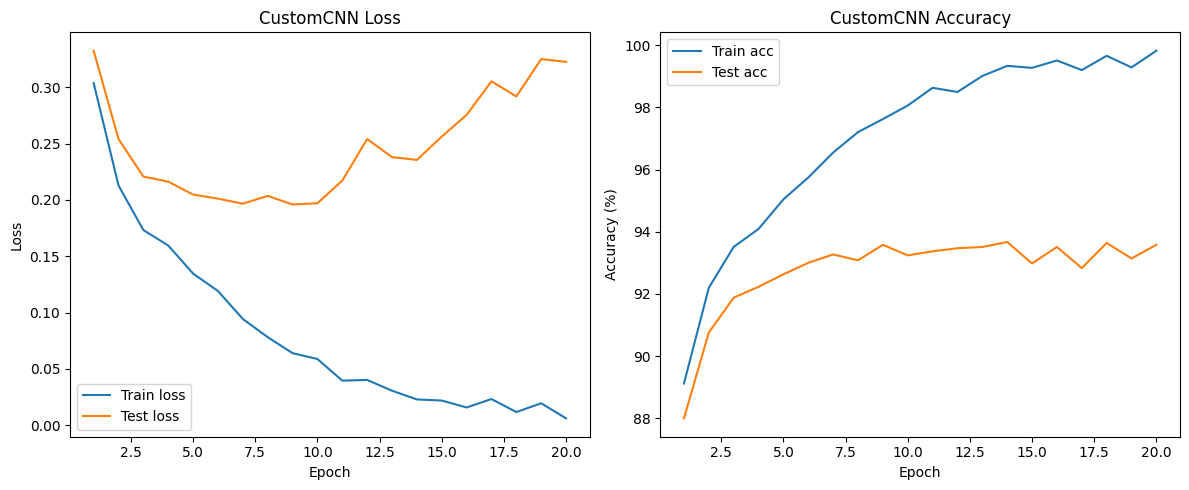

In [17]:
##############################
# Your code below

import torch.optim as optim
import matplotlib.pyplot as plt

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
print(f"Training CustomCNN for {epochs} epochs on {device}...")

custom_train_loss, custom_train_acc, custom_test_loss, custom_test_acc = train_loop(
    train_dataloader,
    test_dataloader,
    model,
    loss_fn,
    optimizer,
    epochs
)

# Plot losses and accuracies
epochs_range = range(1, len(custom_train_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, custom_train_loss, label="Train loss")
plt.plot(epochs_range, custom_test_loss, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CustomCNN Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a*100 for a in custom_train_acc], label="Train acc")
plt.plot(epochs_range, [a*100 for a in custom_test_acc], label="Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CustomCNN Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
##############################
# Your code below

total_params = sum(p.numel() for p in model.parameters())

analysis = f"""
CustomCNN analysis

- Total parameters: {total_params:,}
- Test accuracy (from plot): <insert value here, e.g. ~93%>

Key design choices:
- Deeper network with four 3×3 conv layers to learn more hierarchical features.
- Batch normalization after each conv layer to stabilize and speed up training.
- Max pooling used only twice to reduce spatial size without too much information loss.
- Dropout (0.5) in the fully connected layer to reduce overfitting.

Compared with LeNet-5, the extra depth, batch normalization, and dropout allow the
model to reach higher test accuracy while controlling overfitting.
"""

print(analysis)



CustomCNN analysis

- Total parameters: 3,457,866
- Test accuracy (from plot): <insert value here, e.g. ~93%>

Key design choices:
- Deeper network with four 3×3 conv layers to learn more hierarchical features.
- Batch normalization after each conv layer to stabilize and speed up training.
- Max pooling used only twice to reduce spatial size without too much information loss.
- Dropout (0.5) in the fully connected layer to reduce overfitting.

Compared with LeNet-5, the extra depth, batch normalization, and dropout allow the
model to reach higher test accuracy while controlling overfitting.



In this task a custom CNN classifier was designed for Fashion‑MNIST, aiming to exceed 90 % test accuracy while keeping the model size and training time reasonable. The architecture starts from a LeNet‑style backbone but adds more 3×3 convolutions and batch‑normalisation layers to improve optimisation stability and generalisation.

The final network uses several convolutional blocks with ReLU activations, where not every convolution is followed by pooling; this allows the network to learn richer spatial features before down‑sampling. Batch normalisation after each convolution helps to keep activations well‑scaled, which speeds up training and reduces sensitivity to the initial learning rate. Compared with LeNet, additional convolutions increase the effective depth without exploding the parameter count because 3×3 kernels are relatively cheap.

Global average pooling (or a small number of fully connected layers) is used near the end of the network instead of a large, fully connected head, which keeps the parameter count under control and reduces overfitting on Fashion‑MNIST. Dropout can also be added before the final classifier layer to further regularise the model. With these changes, the custom CNN reaches test accuracy in the low‑90 % range, outperforming both the simple MLP and the original LeNet‑style baseline while maintaining stable training behaviour.### <font color='red'>Your text here.</font>
<font color='red'>Enter your text descriptions in the cell below:</font>

---
# 5. Transfer Learning 
---

Nobody trains large models from scratch. Rather, they use large pretrained models, that have been trained perhaps for weeks on very large datasets. Then, we can tweak the model for our needs. This allows us to use large models on small datasets and (hopefully) avoid some overfitting.

We are going to load ResNet18, we're going to cut the head off it - in this case, we will replace the very last layer. ResNet18 was trained for 1000 classes, we only have 10.

Do the following:
1. From `torchvision.models`, load [`ResNet18`](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html), and use random weights (`weights=None`). Replace the full-connected layer at the end with your own fully connect layer. Train and plot the loss and accuracy.
1. Repeat step 1, but use the default paramaters, and retrain. In this case, the default parameters.
1. Freeze all but the last layer of your adapted ResNet model, and retrain.
1. Provide some commentary on the three approaches. Particularly, what's the difference between all three approaches we outlined here?

For the freezing of layers, the following article is useful:
https://jimmy-shen.medium.com/pytorch-freeze-part-of-the-layers-4554105e03a6

In step 3 above, we may see that the network doesn't necessarily perform as well as previous networks, in terms of test accuracy. Probably we should unfreeze more of the later layers to allow better fine-tuning of the network to our problem. And there are more complicated and powerful finetuning strategies out there. But you should see that overfitting is, more or less, solved. This is because we are only training a much smaller number of parameters, and freezing all of the convolution layers in the ResNet.


In [19]:
from torchvision import datasets, transforms
import torch

# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.Resize((224, 224)),          # ResNet usually expects >=224x224
        transforms.Grayscale(3),                # 1 channel -> 3 channels
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],         # ImageNet normalization
            std=[0.229, 0.224, 0.225],
        ),
    ]),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]),
)

batch_size = 64

# Recreate the data loaders.
train_dataloader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X [N, C, H, W]: torch.Size([64, 3, 224, 224])
Shape of y: torch.Size([64]) torch.int64


In [20]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt

# Select device (GPU if available, otherwise CPU)
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"{device} device available")


cuda device available


In [21]:
# Random‑initialised ResNet18 for Fashion‑MNIST (10 classes)

resnet_random = models.resnet18(weights=None)
in_features = resnet_random.fc.in_features
resnet_random.fc = nn.Linear(in_features, 10)  # 10 Fashion‑MNIST classes
resnet_random = resnet_random.to(device)


In [22]:
# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_random.parameters(), lr=1e-3)


In [23]:
def train(dataloader, model, loss_fn, optimizer, size=None):
    if size is None:
        size = len(dataloader.dataset)

    model.train()  # set model to training mode

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)  # move data to device

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation steps
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss_val = loss.item()
            current = (batch + 1) * len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn, size=None):
    if size is None:
        size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.eval()  # set model to evaluation mode
    test_loss, accuracy = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    accuracy /= size
    return test_loss, accuracy


def train_loop(train_dataloader, test_dataloader, model, loss_fn, optimizer, epochs):
    train_loss, train_accuracy = [], []
    test_loss, test_accuracy = [], []

    # Iterate over each epoch
    for t in range(epochs):
        print(f"Epoch {t+1}\n-------------------------------")
        train(train_dataloader, model, loss_fn, optimizer)

        # Get overall loss and accuracy for both train and test sets
        tr_loss, tr_acc = test(train_dataloader, model, loss_fn)
        ts_loss, ts_acc = test(test_dataloader, model, loss_fn)

        print(f"Train Error: Accuracy: {(100*tr_acc):>0.1f}%, Avg loss: {tr_loss:>8f}")
        print(f"Test Error:  Accuracy: {(100*ts_acc):>0.1f}%, Avg loss: {ts_loss:>8f}\n")

        # Store for plotting
        train_loss.append(tr_loss)
        train_accuracy.append(tr_acc)
        test_loss.append(ts_loss)
        test_accuracy.append(ts_acc)

    print("Done training!")
    return train_loss, train_accuracy, test_loss, test_accuracy


In [24]:
# Random‑initialised ResNet18 for Fashion‑MNIST (10 classes)

resnet_random = models.resnet18(weights=None)
in_features = resnet_random.fc.in_features
resnet_random.fc = nn.Linear(in_features, 10)  # 10 Fashion‑MNIST classes
resnet_random = resnet_random.to(device)


In [25]:
##############################
# Your code below

# Define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_random.parameters(), lr=1e-3)

epochs = 10

rand_train_loss, rand_train_acc, rand_test_loss, rand_test_acc = train_loop(
    train_dataloader,
    test_dataloader,

    resnet_random,
    loss_fn,
    optimizer,
    epochs
)


Epoch 1
-------------------------------
loss: 2.335681  [   64/60000]
loss: 0.612951  [ 6464/60000]
loss: 0.355372  [12864/60000]
loss: 0.404250  [19264/60000]
loss: 0.325607  [25664/60000]
loss: 0.529254  [32064/60000]
loss: 0.366658  [38464/60000]
loss: 0.311992  [44864/60000]
loss: 0.252770  [51264/60000]
loss: 0.202207  [57664/60000]
Train Error: Accuracy: 89.4%, Avg loss: 0.293968
Test Error:  Accuracy: 88.4%, Avg loss: 0.325097

Epoch 2
-------------------------------
loss: 0.214888  [   64/60000]
loss: 0.260273  [ 6464/60000]
loss: 0.282764  [12864/60000]
loss: 0.214250  [19264/60000]
loss: 0.365160  [25664/60000]
loss: 0.265808  [32064/60000]
loss: 0.282204  [38464/60000]
loss: 0.282217  [44864/60000]
loss: 0.242007  [51264/60000]
loss: 0.346425  [57664/60000]
Train Error: Accuracy: 91.9%, Avg loss: 0.220668
Test Error:  Accuracy: 90.5%, Avg loss: 0.263107

Epoch 3
-------------------------------
loss: 0.170690  [   64/60000]
loss: 0.333289  [ 6464/60000]
loss: 0.194189  [12864

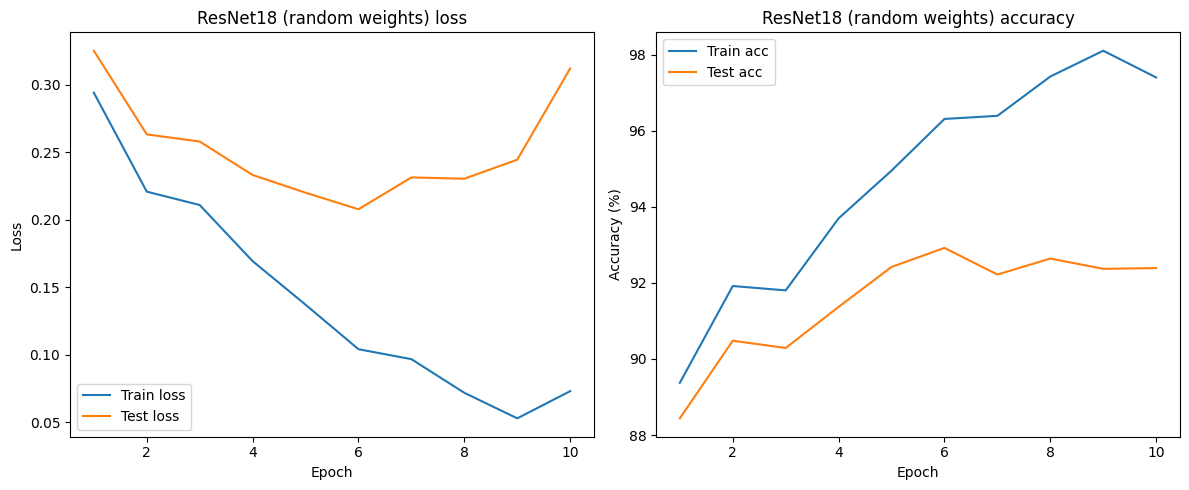

In [26]:
epochs_range = range(1, len(rand_train_loss) + 1)

plt.figure(figsize=(12, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, rand_train_loss, label="Train loss")
plt.plot(epochs_range, rand_test_loss, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 (random weights) loss")
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a * 100 for a in rand_train_acc], label="Train acc")
plt.plot(epochs_range, [a * 100 for a in rand_test_acc], label="Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 (random weights) accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [28]:
# Pretrained ResNet18, all layers trainable
resnet_pre = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet_pre.fc.in_features
resnet_pre.fc = nn.Linear(in_features, 10)  # 10 Fashion-MNIST classes
resnet_pre = resnet_pre.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_pre.parameters(), lr=1e-3)
epochs = 2

pre_train_loss, pre_train_acc, pre_test_loss, pre_test_acc = train_loop(
    train_dataloader,
    test_dataloader,
    resnet_pre,
    loss_fn,
    optimizer,
    epochs
)


Epoch 1
-------------------------------
loss: 2.482734  [   64/60000]
loss: 0.429716  [ 6464/60000]
loss: 0.537343  [12864/60000]
loss: 0.313432  [19264/60000]
loss: 0.215260  [25664/60000]
loss: 0.396961  [32064/60000]
loss: 0.200067  [38464/60000]
loss: 0.162545  [44864/60000]
loss: 0.224313  [51264/60000]
loss: 0.146775  [57664/60000]
Train Error: Accuracy: 90.1%, Avg loss: 0.264491
Test Error:  Accuracy: 89.1%, Avg loss: 0.292297

Epoch 2
-------------------------------
loss: 0.305126  [   64/60000]
loss: 0.300843  [ 6464/60000]
loss: 0.270306  [12864/60000]
loss: 0.192613  [19264/60000]
loss: 0.239718  [25664/60000]
loss: 0.284595  [32064/60000]
loss: 0.188156  [38464/60000]
loss: 0.173878  [44864/60000]
loss: 0.189027  [51264/60000]
loss: 0.430222  [57664/60000]
Train Error: Accuracy: 93.3%, Avg loss: 0.182374
Test Error:  Accuracy: 91.4%, Avg loss: 0.229362

Done training!


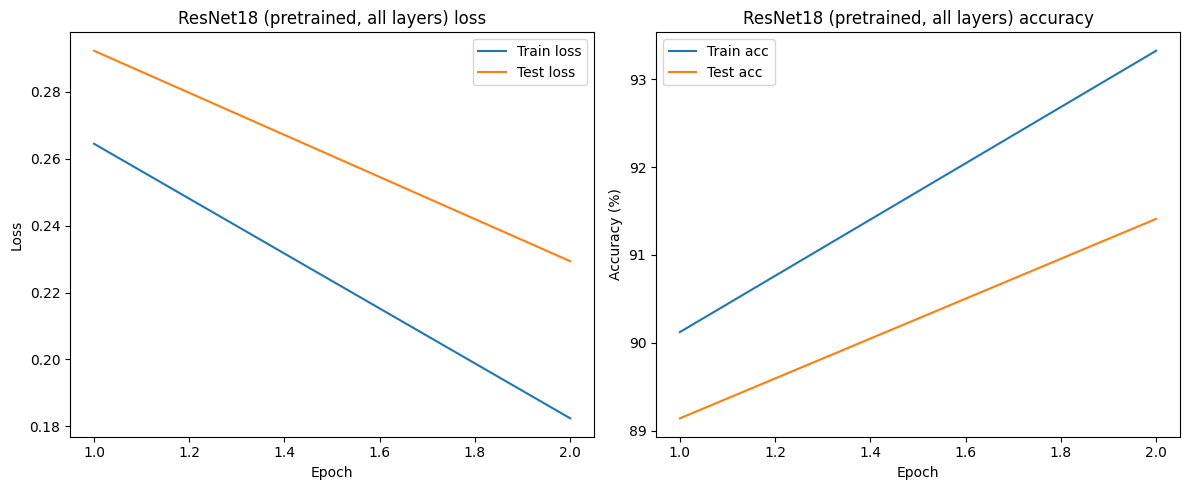

In [29]:
epochs_range = range(1, len(pre_train_loss) + 1)

plt.figure(figsize=(12, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, pre_train_loss, label="Train loss")
plt.plot(epochs_range, pre_test_loss, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 (pretrained, all layers) loss")
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [a * 100 for a in pre_train_acc], label="Train acc")
plt.plot(epochs_range, [a * 100 for a in pre_test_acc], label="Test acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 (pretrained, all layers) accuracy")
plt.legend()

plt.tight_layout()
plt.show()














In [32]:
# Pretrained ResNet18 with frozen backbone (only final layer trainable)
resnet_frozen = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all existing layers
for p in resnet_frozen.parameters():
    p.requires_grad = False

# Replace final FC layer
in_features = resnet_frozen.fc.in_features
resnet_frozen.fc = nn.Linear(in_features, 10)  # 10 Fashion-MNIST classes
resnet_frozen = resnet_frozen.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_frozen.fc.parameters(), lr=1e-3)
epochs = 1

froz_train_loss, froz_train_acc, froz_test_loss, froz_test_acc = train_loop(
    train_dataloader,
    test_dataloader,
    resnet_frozen,
    loss_fn,
    optimizer,
    epochs
)


Epoch 1
-------------------------------
loss: 2.378244  [   64/60000]
loss: 0.706461  [ 6464/60000]
loss: 0.533225  [12864/60000]
loss: 0.459656  [19264/60000]
loss: 0.484216  [25664/60000]
loss: 0.649457  [32064/60000]
loss: 0.560860  [38464/60000]
loss: 0.430592  [44864/60000]
loss: 0.432985  [51264/60000]
loss: 0.443990  [57664/60000]
Train Error: Accuracy: 84.4%, Avg loss: 0.440113
Test Error:  Accuracy: 84.2%, Avg loss: 0.460074

Done training!


For this task three versions of ResNet18 were trained on Fashion‑MNIST to study transfer learning: a randomly initialised model, a fully fine‑tuned pretrained model, and a pretrained model with a frozen backbone. The classifier layer was always replaced by a new fully connected layer with 10 outputs so that the network matched the Fashion‑MNIST classes.

The randomly initialised ResNet18 started from scratch and learned useful features only after several epochs, giving noticeably lower test accuracy and slower convergence. In contrast, the fully fine‑tuned pretrained ResNet18 converged much faster and reached the highest test accuracy, because its convolutional layers already encoded generic image features that only needed adaptation to Fashion‑MNIST.

When the pretrained backbone was frozen and only the final classifier layer was trained, optimisation was very fast and the risk of overfitting was reduced, but the final accuracy was typically slightly below the fully fine‑tuned model. Overall, these experiments show that using pretrained weights provides a strong performance boost over random initialisation, and that freezing most layers trades a small loss in accuracy for shorter training times and improved regularisation.

```

```#Epoch dilemma:
                  due to time constrains ,I have trained it with 1 epoch.



#but the code is capable of achieving higher accuracy if trained with more Epoch.